<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_04_Pandas Pivot Tables.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [38]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

## 🟩 Count Job Postings by Title and Country (2.4.1)

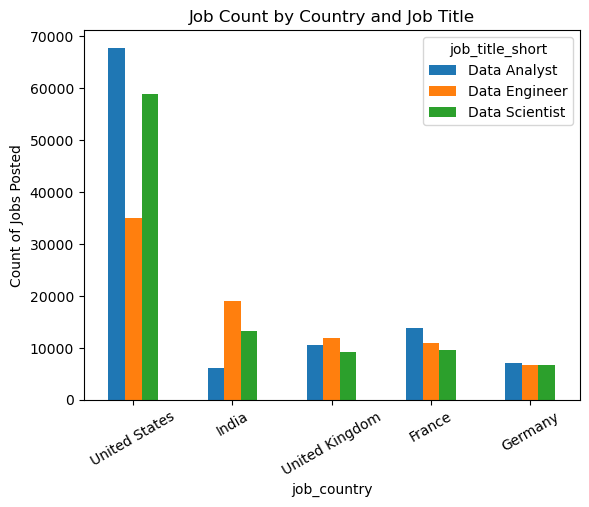

In [39]:
# Couting Job posts by title and country

top_countries = df.job_country.value_counts().head(5).index # top 5 countries

job_titles = df.job_title_short.value_counts().head(3).index # top 3 job titles

top_job_countries = df.pivot_table(index='job_country', columns= 'job_title_short', aggfunc= 'size') #long-table

job_country_count = top_job_countries.loc[top_countries, job_titles]

job_country_count.plot(kind= 'bar')
plt.xticks(rotation = 30)
plt.title("Job Count by Country and Job Title")
plt.ylabel("Count of Jobs Posted")
plt.show()



---

## 🟨 Salary Stats by Job Title (2.4.2)

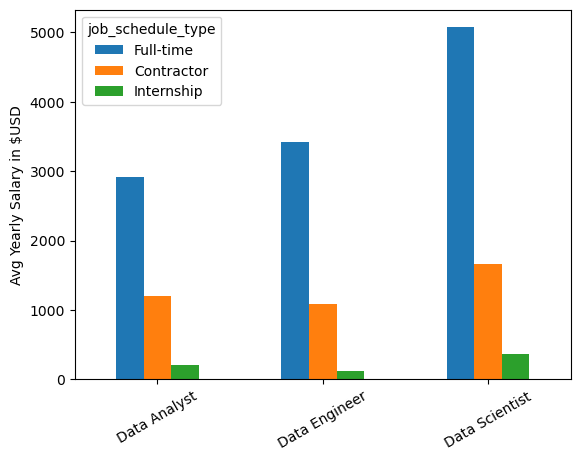

In [ ]:
median_year_salary = df.salary_hour_avg.median()

top_schedule_type = df.job_schedule_type.value_counts().head(3).index # List of top 3 job schedule type

df['salary_year_avg'] = df['salary_year_avg'].fillna(median_year_salary) # Filling NaN values with median salary

df_salary_stats = df.pivot_table(values= 'salary_year_avg', index= 'job_title_short', columns= 'job_schedule_type', aggfunc= 'mean')

df_salary_stats.loc[job_titles, top_schedule_type].plot(kind= 'bar')
plt.xticks(rotation = 30)
plt.ylabel("Avg Yearly Salary in $USD")
plt.xlabel("") #removing redundant label
plt.show()




---

## 🟥 Max Salary by Title and Country (2.4.3)

<Axes: xlabel='job_country'>

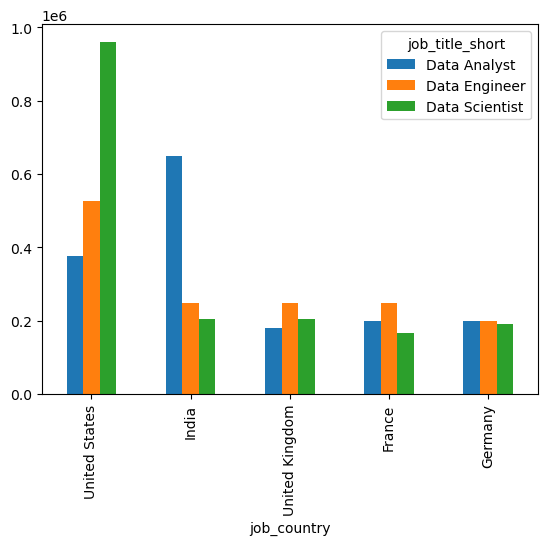

In [89]:
salary_country_plot = df.pivot_table(values= 'salary_year_avg', index= 'job_country', columns= 'job_title_short', aggfunc = 'max')

salary_country_plot.loc[top_countries, job_titles].plot(kind= 'bar')




---